In [31]:
import numpy as np
import matplotlib.pyplot as plt

import copy
import math

def compute_cost_nfeatures(x, y, w, b):
    m = x.shape[0]
    loss_sum = 0
    for i in range(m):
        predict = np.dot(x[i], w) + b # single feature : w*x[i] + b #y^
        loss = (predict - y[i]) ** 2
        loss_sum += loss
    cost = loss_sum * (1/(2*m))
    return cost
def compute_gradient_nfeatures(x, y, w, b):
    # m = x.shape[0]
    # n = x.shape[1]
    m, n = x.shape
    dj_dw = np.zeros(n) # or np.zeros((n,))
    dj_db = 0
    for i in range(m):
        predict = np.dot(x[i], w) + b # predict using all feature in a row
        loss = predict - y[i] # loss for all features in a row
        # update dj_dw for each feature
        for j in range(n):
            dj_dw[j] += loss*x[i,j] # loss from all features * value form each single feature
        dj_db += loss
    
    dj_dw/=m
    dj_db/=m
    return dj_dw, dj_db
def gradient_descent(x, y, w, b, alpha, epochs, compute_cost_nfeatures, compute_gradient_nfeatures):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    m, n = x.shape
    cost_history = []
    params_history = []

    for i in range(epochs):
        #Calc Gradients
        dj_dw, dj_db = compute_gradient_nfeatures(x, y, w, b)
        #Update Parameters
        w -= alpha * dj_dw # Update each weight using its corresponding gradient, Element-wise update: w[j] = w[j] - alpha * dj_dw[j]
        b -= alpha * dj_db

        # Resource exacution
        if i < 10000:
            cost = compute_cost_nfeatures(x, y, w, b)
            cost_history.append(cost)
            params_history.append([w.copy(),b]) # as w is array, every iteration wil store same reference so use copy
        #Print Status
        if i% math.ceil(epochs/10) == 0:# after each 10 percent of epochs
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f} dj_dw : {dj_dw} w : {w}")

    return w, b, cost_history, params_history


<a name='PolynomialFeatures'></a>
## Polynomial Features

Above we were considering a scenario where the data was non-linear. Let's try using what we know so far to fit a non-linear curve. We'll start with a simple quadratic: $y = 1+x^2$

You're familiar with all the routines we're using. They are available in the lab_utils.py file for review. We'll use [`np.c_[..]`](https://numpy.org/doc/stable/reference/generated/numpy.c_.html) which is a NumPy routine to concatenate along the column boundary.

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[   1    2    9   28   65  126  217  344  513  730 1001 1332 1729 2198
 2745 3376 4097 4914 5833 6860]
[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]]
Iteration    0: Cost 799566.31 dj_dw : [-28142.8] w : [281.428]
Iteration  100: Cost 510356.93 dj_dw : [-21.30967204] w : [250.99352468]
Iteration  200: Cost 451094.75 dj_dw : [-16.29989409] w : [269.66151769]
Iteration  300: Cost 416421.56 dj_dw : [-12.46788533] w : [283.94077588]
Iteration  400: Cost 396134.94 dj_dw : [-9.53675918] w : [294.86306487]
Iteration  500: Cost 384265.63 dj_dw : [-7.29472347] w : [303.21758828]
Iteration  600: Cost 377321.11 dj_dw : [-5.5797771] w : [309.60801261]
Iteration  700: Cost 373258.01 dj_dw : [-4.26800448] w : [314.49608595]
Iteration  800: Cost 370880.76 dj_dw : [-3.26462185] w : [318.23500214]
Iteration  900: Cost 369489.88 dj_dw : [-2.49712855] w : [321.09492124]


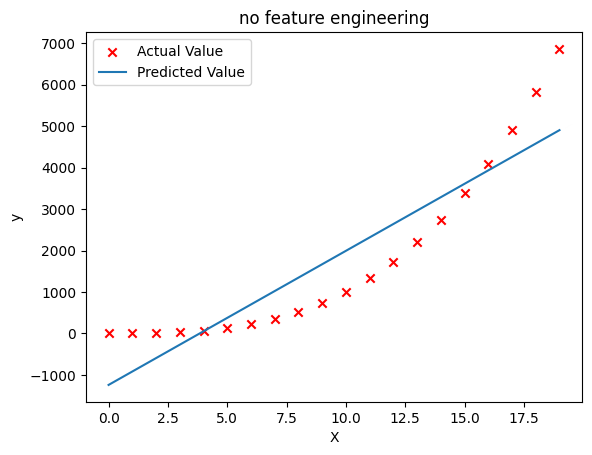

In [ ]:
x = np.arange(0, 20, 1) # array from 0-19
print(x)
y = 1 + x**2
print(y)
X = x.reshape(-1, 1)
print(X)
x = np.arange(0,20)

plt.figure(figsize=(8,5))

plt.plot(x, 1+x, label="x")
plt.plot(x, 1+x**2, label="x²")
plt.plot(x, 1+x**3, label="x³")
plt.plot(x, 1+x**4, label="x⁴")

plt.legend()
plt.grid(True)
plt.show()
w_init = np.array([0.0])
b_init = 0
w_final, b_final , cost_history, param_history = gradient_descent(X, y, w_init, b_init, 1e-2, 1000, compute_cost_nfeatures, compute_gradient_nfeatures)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@w_final + b_final, label="Predicted Value");  plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()